In [41]:
#Import Required Libraries:

In [1]:
import pandas as pd
import numpy as np

# Visualization (optional)
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

In [2]:
#Load Dataset:

In [4]:
df = pd.read_csv("credit_score.csv")

In [5]:
df.head()

,Age,Gender,Education,Income,Debt,Credit_Score,Loan_Amount,Loan_Term,Num_Credit_Cards,Payment_History,Employment_Status,Residence_Type,Marital_Status,Creditworthiness
0,56,Female,Master,149406,34089,581,49200,60,4,Bad,Unemployed,Rented,Single,1
1,69,Female,High School,78896,8626,648,20147,24,7,Good,Employed,Mortgaged,Married,1
2,46,Female,Master,119339,46281,329,41307,12,8,Bad,Unemployed,Owned,Single,1
3,32,Male,High School,131067,29403,816,19019,60,8,Bad,Employed,Owned,Single,1
4,60,Male,PhD,38001,30032,673,16317,36,4,Average,Employed,Rented,Married,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                12000 non-null  int64 
 1   Gender             12000 non-null  object
 2   Education          12000 non-null  object
 3   Income             12000 non-null  int64 
 4   Debt               12000 non-null  int64 
 5   Credit_Score       12000 non-null  int64 
 6   Loan_Amount        12000 non-null  int64 
 7   Loan_Term          12000 non-null  int64 
 8   Num_Credit_Cards   12000 non-null  int64 
 9   Payment_History    12000 non-null  object
 10  Employment_Status  12000 non-null  object
 11  Residence_Type     12000 non-null  object
 12  Marital_Status     12000 non-null  object
 13  Creditworthiness   12000 non-null  int64 
dtypes: int64(8), object(6)
memory usage: 1.3+ MB


In [7]:
df.shape

(12000, 14)

In [8]:
df.describe()

,Age,Income,Debt,Credit_Score,Loan_Amount,Loan_Term,Num_Credit_Cards,Creditworthiness
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,43.489250,85222.009417,25354.673250,573.967583,25113.951250,35.943000,4.985833,0.702583
std,14.908982,37640.043409,14087.390846,157.816052,14247.092051,16.965162,2.593458,0.457140
min,18.000000,20026.000000,1001.000000,300.000000,501.000000,12.000000,1.000000,0.000000
25%,31.000000,52400.750000,13161.000000,437.000000,12725.000000,24.000000,3.000000,0.000000
50%,43.000000,85756.000000,25382.500000,574.000000,25220.500000,36.000000,5.000000,1.000000
75%,56.000000,117754.750000,37497.500000,709.000000,37348.000000,48.000000,7.000000,1.000000
max,69.000000,149984.000000,49995.000000,849.000000,49996.000000,60.000000,9.000000,1.000000


In [ ]:
#Data Preprocessing:

In [30]:
# Check missing values
print(df.isnull().sum())

# Encode categorical variables
label_encoders = {}

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

Age                  0
Gender               0
Education            0
Income               0
Debt                 0
Credit_Score         0
Loan_Amount          0
Loan_Term            0
Num_Credit_Cards     0
Payment_History      0
Employment_Status    0
Residence_Type       0
Marital_Status       0
Creditworthiness     0
dtype: int64


In [ ]:
#Define Features and Target:

In [32]:
X = df.drop("Creditworthiness", axis=1)
y = df["Creditworthiness"]

In [ ]:
#Train-Test Split:

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#eature Scaling (for Logistic Regression):

In [34]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#Train Classification Models
#Logistic Regression:

In [35]:
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)
log_prob = log_model.predict_proba(X_test_scaled)[:,1]

In [ ]:
#Decision Tree:

In [36]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:,1]

In [ ]:
#Random Forest:

In [37]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

In [ ]:
#Model Evaluation
#Precision, Recall, F1-score:

In [38]:
print("Logistic Regression")
print(classification_report(y_test, log_pred))

print("Decision Tree")
print(classification_report(y_test, dt_pred))

print("Random Forest")
print(classification_report(y_test, rf_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       716
           1       0.70      1.00      0.82      1684

    accuracy                           0.70      2400
   macro avg       0.35      0.50      0.41      2400
weighted avg       0.49      0.70      0.58      2400

Decision Tree
              precision    recall  f1-score   support

           0       0.29      0.01      0.01       716
           1       0.70      0.99      0.82      1684

    accuracy                           0.70      2400
   macro avg       0.50      0.50      0.42      2400
weighted avg       0.58      0.70      0.58      2400

Random Forest
              precision    recall  f1-score   support

           0       0.24      0.01      0.01       716
           1       0.70      0.99      0.82      1684

    accuracy                           0.70      2400
   macro avg       0.47      0.50      0.42      2400
weighted avg       0.56   

C:\Users\TOSHIBA\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\TOSHIBA\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\TOSHIBA\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#ROC-AUC Score:

In [39]:
print("Logistic ROC-AUC:", roc_auc_score(y_test, log_prob))
print("Decision Tree ROC-AUC:", roc_auc_score(y_test, dt_prob))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf_prob))

Logistic ROC-AUC: 0.49770846879602965
Decision Tree ROC-AUC: 0.5205279893576082
Random Forest ROC-AUC: 0.49504165063230676


In [ ]:
#ROC Curve Visualization:

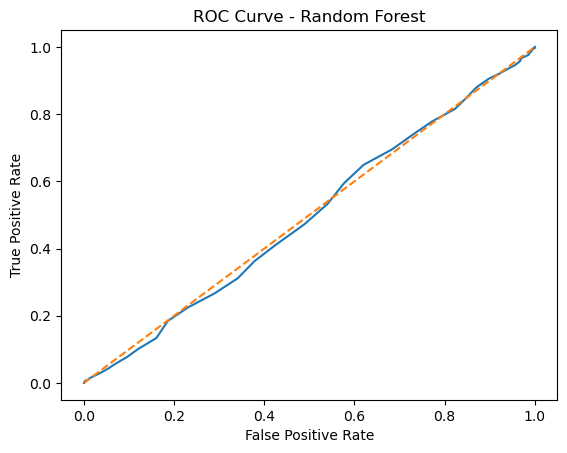

In [40]:
fpr, tpr, _ = roc_curve(y_test, rf_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.show()